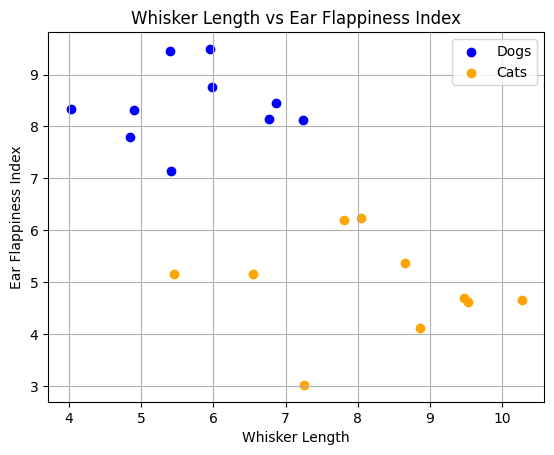

Best theta: [-1.07075262  1.05445173]
Best theta0: -0.40317694697317963


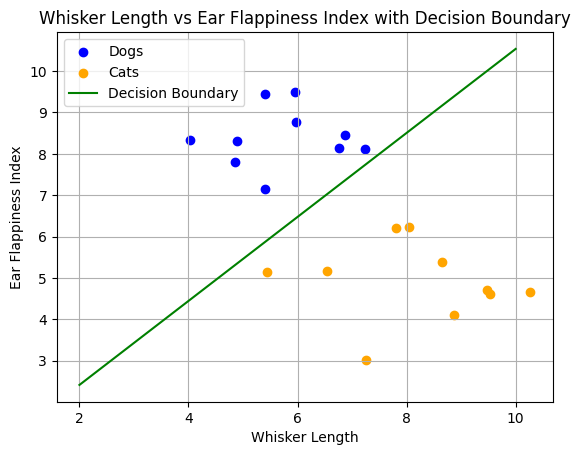

In [2]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0) #for reproducibility
# Dog: higher ear flappiness indx and lower whisker length
dogs_whisker_length = np.random.normal(loc=5,scale=1,size=10) #x coordinate for dogs
#whsker length is normally distributed with mean 5 and standard deviation 1 , 10 samples
dogs_ear_flappiness_index = np.random.normal(loc=8,scale=1,size=10) #y coordinate for dogs
#ear flappiness index is normally distributed with mean 8 and standard deviation 1, 10 samples
# Cats: lower ear flappiness indx and higher whisker length
cats_whisker_length = np.random.normal(loc=8,scale=1,size=10) #x coordinate for cats
#whsker length is normally distributed with mean 3 and standard deviation 1 , 10 samples
cats_ear_flappiness_index = np.random.normal(loc=5,scale=1,size=10) #y coordinate for cats
#ear flappiness index is normally distributed with mean 10 and standard deviation 1, 10 samples
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, color='blue', label='Dogs')
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, color='orange', label='Cats')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Whisker Length vs Ear Flappiness Index')
plt.legend()
plt.grid()
plt.show()
#implementing the random linear classifier
#we will use a simple linear decision boundary to classify the data points

def random_linear_classifier(dogs_data, cats_data, k,d):
  #d: number of features (in this case 2: whisker length and ear flappiness index)
  best_error = float('inf')
  best_theta = None
  best_theta0 = None

  #step1: choose k random linear classifiers
  for _ in range(k): 
    #step2: randomly initialize theta and theta0
    theta = np.random.normal(size=d) #randomly initialize theta 
    theta0 = np.random.normal() #randomly initialize theta0

    #step3: compute the classification error for the current classifier
    error = compute_error(dogs_data, cats_data, theta, theta0) #compute the classification error
    if error < best_error:
      best_error = error
      best_theta = theta
      best_theta0 = theta0

  return best_theta, best_theta0
def compute_error(dogs_data, data_cats, theta, theta0):
  error=0
  for x_dog in dogs_data:
    if np.dot(theta, x_dog) + theta0 <= 0: #if the classifier predicts cat for a dog
      error += 1
  for x_cat in cats_data:
    if np.dot(theta, x_cat) + theta0 > 0: #if the classifier predicts dog for a cat
      error += 1
  return error

#prepare dataset for classification
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T #combine whisker length and ear flappiness index for dogs
cats_data = np.vstack((cats_whisker_length, cats_ear_flappiness_index)).T #combine whisker length and ear flappiness index for cats
dogs_data, cats_data
k=100 #number of random classifiers to try
d=2 #number of features
best_theta, best_theta0 = random_linear_classifier(dogs_data, cats_data, k, d)
print("Best theta:", best_theta)
print("Best theta0:", best_theta0)
#plot the decision boundary
x_vals = np.linspace(2, 10, 100)
y_vals = (-best_theta[0]/best_theta[1]) * x_vals - (best_theta0 / best_theta[1])
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index, color='blue', label='Dogs')
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, color='orange', label='Cats')
plt.plot(x_vals, y_vals, color='green', label='Decision Boundary')
plt.xlabel('Whisker Length')
plt.ylabel('Ear Flappiness Index')
plt.title('Whisker Length vs Ear Flappiness Index with Decision Boundary')
plt.legend()
plt.grid()
plt.show()